In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Define the project directory path
PROJECT_DIR = "/content/drive/My Drive/Colab Notebooks/projects/"

#Load the CSSV into a Dataframe
data = pd.read_csv(PROJECT_DIR + "sacco_data.csv")

#Inspect the data
print("--- Data Shape ---")
print(data.shape)

print("\n--- Data Types---")
print(data.dtypes)

print("\n--- Statistical Summary ---")
data.describe().round(2)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Data Shape ---
(200, 17)

--- Data Types---
Member_ID             object
County                object
Gender                object
Age                    int64
Marital_Status        object
Education_Level       object
Business_Type         object
Months_As_Member       int64
Dependants             int64
Monthly_Income         int64
Savings                int64
Loan_Amount            int64
Loan_Purpose          object
Loan_Status           object
Loan_Income_Ratio    float64
Savings_Rate         float64
Total_Assets           int64
dtype: object

--- Statistical Summary ---


,Age,Months_As_Member,Dependants,Monthly_Income,Savings,Loan_Amount,Loan_Income_Ratio,Savings_Rate,Total_Assets
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,41.12,42.62,2.89,63841.70,17310.22,132423.95,2.05,0.27,66822.68
std,11.84,22.50,2.03,21799.57,9499.78,120066.06,1.63,0.10,30842.50
min,22.00,3.00,0.00,15000.00,5000.00,0.00,0.00,0.08,9531.00
25%,31.00,23.00,1.00,49576.50,9461.00,0.00,0.00,0.19,38307.25
50%,41.00,42.00,3.00,62354.50,15929.50,113906.50,2.03,0.27,68084.50
75%,52.00,63.00,5.00,77567.75,23496.50,213436.75,3.35,0.36,91599.75
max,61.00,83.00,6.00,128571.00,52824.00,453244.00,4.95,0.45,142109.00


## Phase 2: Data Quality Diagnostics
Before performing Exploratory Data Analysis, the raw dataset must be validated to prevent downstream statistical bias.

**Diagnostic Objectives:**
* Identify and statistically treat missing values (`NaN`).
* Remove duplicate member entries.
* Validate numerical boundaries (e.g., ensuring `Age` falls within expected adult ranges of 18-70).
* Verify categorical integrity in the `Loan_Status` column.

In [ ]:
#check for missing values
print("--- Missing Values ---")
print(data.isnull().sum())
#check for duplicates
print("\n--- Duplicates ---")
print(data.duplicated().sum())
#validate age
print("Age out of range:", ((data["Age"] < 18) | (data["Age"] > 70)).sum())
#valid loan status categories
print("\n--- Loan Status Categories ---")
print(data["Loan_Status"].unique())

--- Missing Values ---
Member_ID             0
County                0
Gender                0
Age                   0
Marital_Status        0
Education_Level       0
Business_Type         0
Months_As_Member      0
Dependants            0
Monthly_Income        0
Savings               0
Loan_Amount           0
Loan_Purpose         54
Loan_Status           0
Loan_Income_Ratio     0
Savings_Rate          0
Total_Assets          0
dtype: int64

--- Duplicates ---
0
Age out of range: 0

--- Loan Status Categories ---
['Defaulted' 'No Loan' 'Performing']


In [ ]:
#save the cleaned dataset to drive before moving on
data.to_csv(PROJECT_DIR + "cleaned_sacco_data.csv", index = False)

### 2.2 Diagnostic Reflections

**1. Why run missing value checks on a "perfect" dataset?**
In real-world business environments, data is rarely perfect. Pipelines break, human data-entry errors occur, and systems change. Trusting data blindly leads to silent failures in downstream models. (In fact, our earlier deeper analysis revealed 54 structural missing values in the `Loan_Purpose` column).

**2. The impact of a massive outlier (e.g., KES 999,999,999):**
A single extreme outlier will heavily skew the arithmetic mean (average) upwards. If this happens, our report might falsely tell the SACCO management that the average member is incredibly wealthy, leading to poor strategic decisions. This is why validating numerical ranges is critical.

**3. The danger of whitespace in text columns:**
Computers read strings literally. To Pandas, `"Nairobi"` and `"Nairobi "` (with a trailing space) are two completely different categories. If we don't strip whitespace, our future `groupby` aggregations and bar charts will incorrectly split one county into two.

## Phase 3: Feature Engineering
To prepare the dataset for segment-level comparison and risk analysis, we must engineer new features from the raw continuous variables. This embeds domain knowledge directly into the dataset.

**Engineered Features:**
* **`Risk_Tier`**: Categorizes members into High, Medium, or Low risk based on their `Loan_Income_Ratio`.
* **`Income_Band`**: Uses statistical discretisation (binning) to group continuous `Monthly_Income` into discrete socioeconomic segments.
* **`Has_Loan`**: A boolean flag (True/False) for rapid filtering of loan-holders.

In [ ]:
#Phase 3: Feature Engineering

#Risk tier function to categories members based on the loan income ratio
def risk_tier(ratio):
  if ratio >2:
    return "High"
  elif ratio > 1:
      return "Medium"
  else:
        return "Low"
data["Risk_Tier"] = data['Loan_Income_Ratio'].apply(risk_tier) #creates a new columns called Risk_Tier

#group members based on their income for segment level comparison
data["Income_Band"] = pd.cut(data["Monthly_Income"], bins=[0, 30_000, 80_000, float("inf")], labels =["low", "Middle","High"]) # the pd.cut() is a pandas tool that that cuts numeric columns to labbelled categories called bins

#Has Loan
data["Has_Loan"] = data['Loan_Amount'] > 0

#Check the results
print("-------Newly Engineered Features -------")
print(data[["Monthly_Income", "Income_Band", "Loan_Amount", "Has_Loan", "Loan_Income_Ratio", "Risk_Tier"]].head())

-------Newly Engineered Features -------
   Monthly_Income Income_Band  Loan_Amount  Has_Loan  Loan_Income_Ratio  \
0           47182      Middle        91713      True             1.9438   
1           65904      Middle            0     False             0.0000   
2           61223      Middle       109108      True             1.7821   
3           71782      Middle            0     False             0.0000   
4           62505      Middle        86518      True             1.3842   

  Risk_Tier  
0    Medium  
1       Low  
2    Medium  
3       Low  
4    Medium  


## Phase 4: Exploratory Data Analysis (EDA)
In this phase, we aggregate the dataset to answer high-level business questions regarding geography, gender, and risk exposure.

**Analytical Objectives:**
* Determine geographic wealth distribution and default risk by County.
* Analyze savings behaviors across different Genders.
* Identify the most profitable Business Types.
* Cross-tabulate engineered `Risk_Tier` against actual `Loan_Status` to validate our risk model.

In [ ]:
# Phase 4: Exploratory Data Analysis

# 1. Income and Savings by County
county_summary = data.groupby("County", observed=False)[["Monthly_Income", "Savings"]].mean().round(2).reset_index()
print("--- County Summary ---")
print(county_summary)

# 2. Default rate by county (using lambda)
default_rate = (
    data.groupby("County", observed=False)["Loan_Status"]
    .apply(lambda x: (x == "Defaulted").mean() * 100) # Multiplying by 100 for percentage
    .reset_index(name="Default_Rate_Pct")
    .sort_values("Default_Rate_Pct", ascending=False)
    .round(2)
)
print("\n--- Default Rate by County ---")
print(default_rate)

# 3. Savings rate by gender
gender_savings = data.groupby("Gender", observed=False)["Savings_Rate"].mean().round(4).reset_index()
print("\n--- Savings Rate by Gender ---")
print(gender_savings)

# 4. Top business types by average income
top_businesses = data.groupby("Business_Type", observed=False)["Monthly_Income"].mean().nlargest(3).reset_index()
print("\n--- Top 3 Business Types by Income ---")
print(top_businesses)

# 5. Risk vs Loan Status (Cross-tabulation)
risk_loan_crosstab = pd.crosstab(data["Risk_Tier"], data["Loan_Status"])
print("\n--- Risk vs Loan Status ---")
print(risk_loan_crosstab)

# 6. Save outputs to Drive as required by the guide
county_summary.to_csv(PROJECT_DIR + "county_summary.csv", index=False)
default_rate.to_csv(PROJECT_DIR + "default_rate_by_county.csv", index=False)
risk_loan_crosstab.to_csv(PROJECT_DIR + "risk_loan_crosstab.csv")
print("\nPhase 4 summary files successfully saved to Google Drive.")

--- County Summary ---
    County  Monthly_Income   Savings
0   Kiambu        71822.63  20871.31
1   Kisumu        49946.10  13561.27
2  Mombasa        64426.33  17231.19
3  Nairobi        82493.40  22114.93
4   Nakuru        52449.35  13399.49

--- Default Rate by County ---
    County  Default_Rate_Pct
4   Nakuru             21.62
3  Nairobi             20.93
0   Kiambu             17.14
2  Mombasa             11.11
1   Kisumu             10.20

--- Savings Rate by Gender ---
   Gender  Savings_Rate
0  Female        0.2779
1    Male        0.2600

--- Top 3 Business Types by Income ---
   Business_Type  Monthly_Income
0  Manufacturing    66110.030303
1      Transport    65978.594595
2         Retail    65597.150000

--- Risk vs Loan Status ---
Loan_Status  Defaulted  No Loan  Performing
Risk_Tier                                  
High                21        0          80
Low                  3       54          11
Medium               8        0          23

Phase 4 summary files s


## Phase 4.1: Custom EDA - Age Group Analysis
To understand generational financial habits, we will first engineer an `Age_Group` feature using `pd.cut()`, and then use `.groupby()` to aggregate average incomes and savings across these demographics.

In [ ]:
from pandas.core import groupby
#Engineeer Age_group column

data["Age_Group"] = pd.cut(data['Age'], bins=[18, 30, 40, 50, 60, 70], labels=["18-29", "30-39", "40-49", "50-59", "60-70"])

#2.Group by Age_Group and calculate metrics
age_analysis = data.groupby("Age_Group", observed=False).agg(
    Total_members=("Member_ID", "count"),
    Avg_Income=("Monthly_Income", "mean"),
    Avg_Savings=("Savings", "mean")
).reset_index()

age_analysis["Avg_Income"] = age_analysis["Avg_Income"].round(2)
age_analysis["Avg_Savings"] = age_analysis["Avg_Savings"].round(2)

print("------- Age Group Analysis -------")

print(age_analysis)

------- Age Group Analysis -------
  Age_Group  Total_members  Avg_Income  Avg_Savings
0     18-29             48    58784.83     14597.33
1     30-39             48    62568.85     17011.79
2     40-49             49    65818.78     18637.24
3     50-59             52    66368.27     18512.81
4     60-70              3    89031.33     22971.67


##Phase 5: Data Visulisation
In this phase , we generate 6 charts to visualize income distribution, default geography, and risk frequecy.

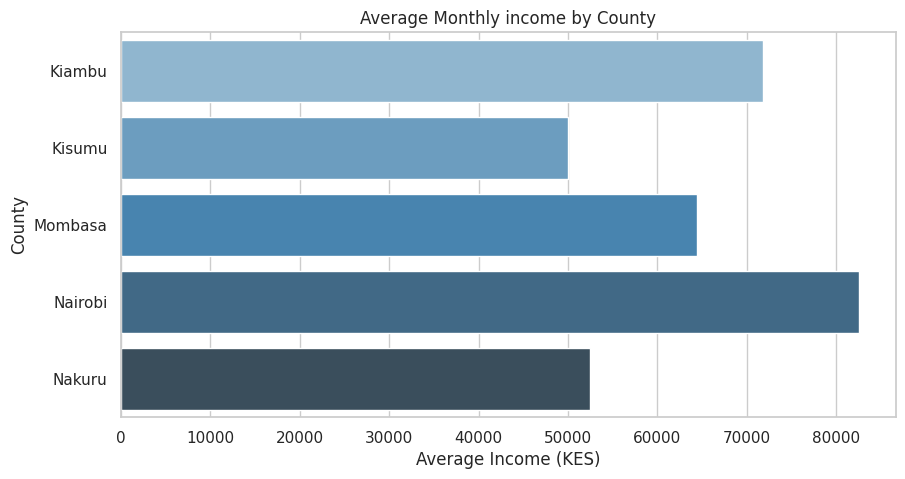

/tmp/ipykernel_21151/1591990934.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="County", y="Default_Rate_Pct", data=default_rate, palette="Reds_r")


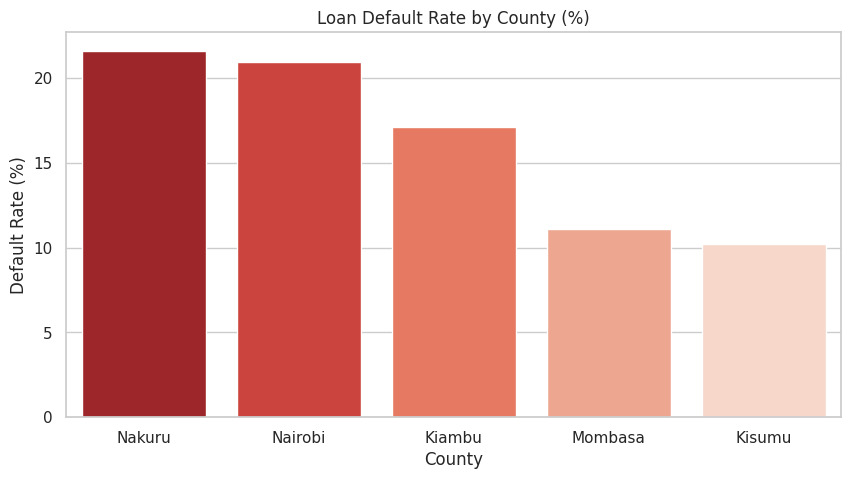

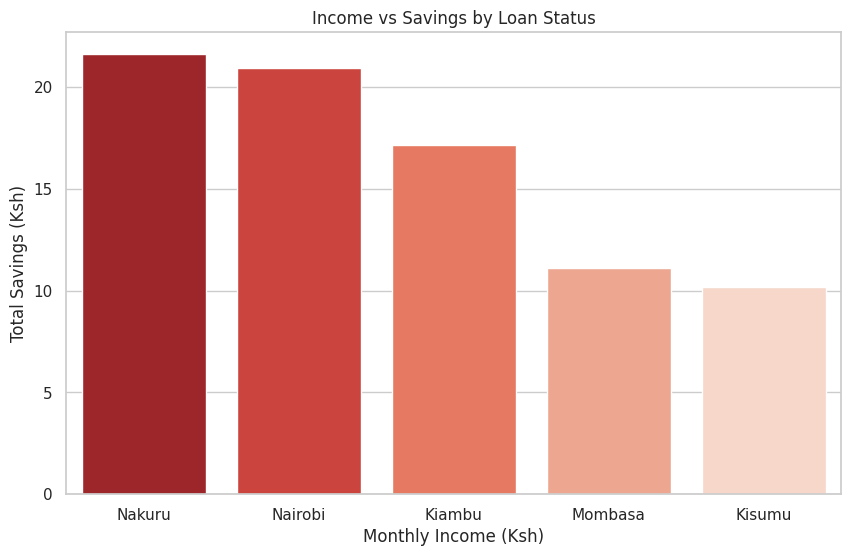

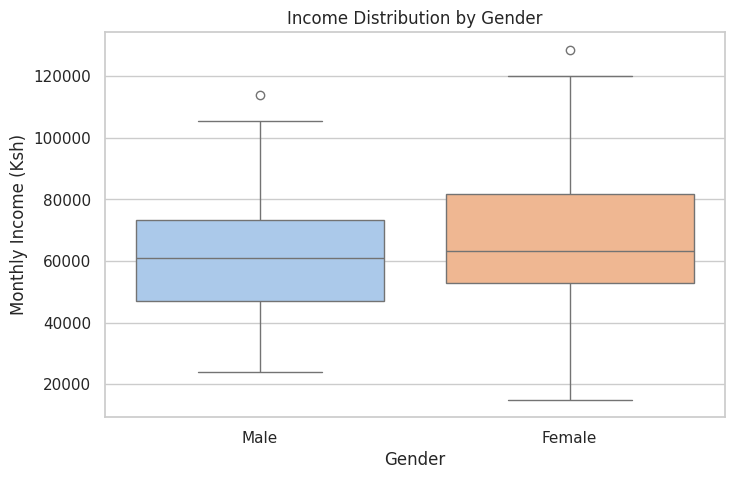

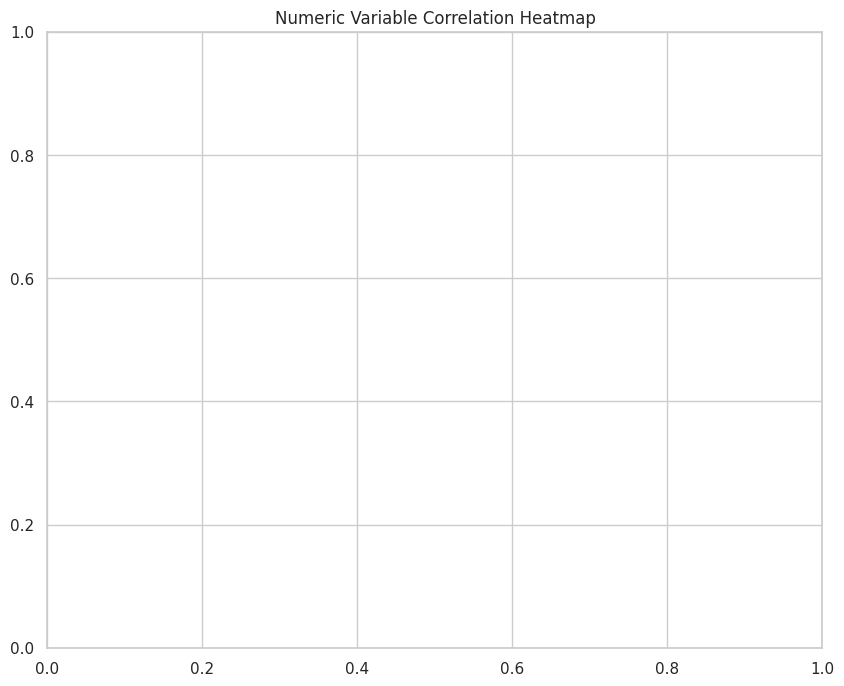

<Figure size 1000x600 with 0 Axes>

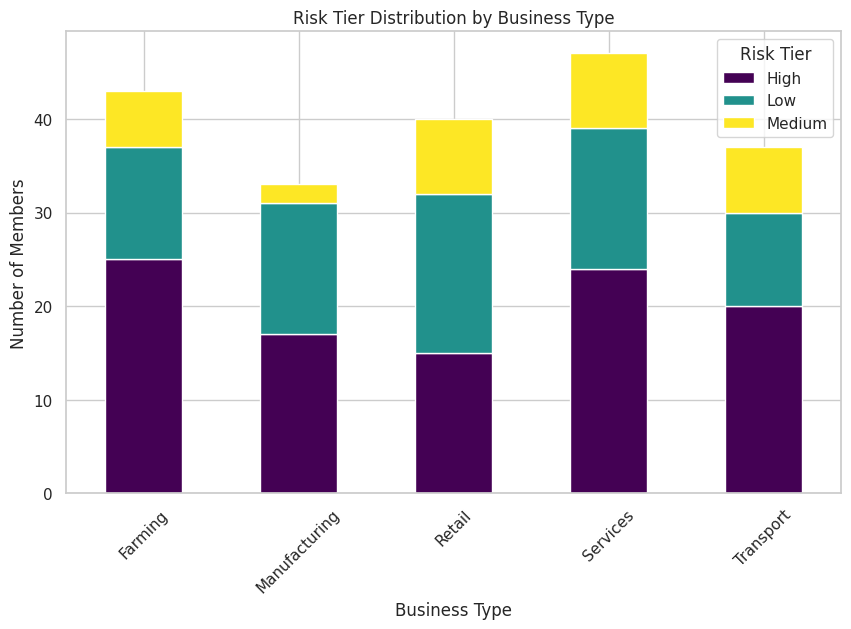

In [ ]:
#Data visualisation
import matplotlib.pyplot as plt #used for data visualisation
import seaborn as sns #used for advanced data visualisation

#setting themes visual style
sns.set_theme(style="whitegrid")# changes the color of the chart to white background for professionalism

# 1.Horizontal Bar:Income by county
plt.figure(figsize=(10, 5)) #creates a black physical canvas, where 10 is the width in inches and 5 is the height
sns.barplot(x="Monthly_Income", y="County", hue="County", data=county_summary, palette="Blues_d", legend=False)
plt.title("Average Monthly income by County") #Displays the title for the Bar
plt.xlabel("Average Income (KES)") # X-axis title
plt.ylabel("County") # Y-axis title
plt.savefig(PROJECT_DIR + "chart1_income_by_county.png", dpi=150, bbox_inches="tight") #we use the tight feature to prevent accidental cutout of the image when it is saved.
plt.show() #Display the chart

# 2. Bar (colour-coded): Default Rate by County
plt.figure(figsize=(10, 5))
sns.barplot(x="County", y="Default_Rate_Pct", data=default_rate, palette="Reds_r")
plt.title("Loan Default Rate by County (%)")
plt.xlabel("County")
plt.ylabel("Default Rate (%)")
plt.savefig(PROJECT_DIR + "chart2_default_rate_by_county.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Scatter Plot: Income vs Savings by Loan Status
plt.figure(figsize=(10, 6))
sns.barplot(x="County", y="Default_Rate_Pct", hue="County", data=default_rate, palette="Reds_r", legend=False)
plt.title("Income vs Savings by Loan Status")
plt.xlabel("Monthly Income (Ksh)")
plt.ylabel("Total Savings (Ksh)")
plt.savefig(PROJECT_DIR + "chart3_income_vs_savings.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Box Plot: Income Distribution by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(x="Gender", y="Monthly_Income", hue="Gender", data=data, palette="pastel", legend=False)
plt.title("Income Distribution by Gender")
plt.ylabel("Monthly Income (Ksh)")
plt.savefig(PROJECT_DIR + "chart4_income_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Filter for numeric columns only to prevent errors
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns #Isolates only the columns containing integers and decimals.
corr_matrix = data[numeric_cols].corr() #we use annot to print the exact numerical correllation inside the colored squares
plt.title("Numeric Variable Correlation Heatmap")
plt.savefig(PROJECT_DIR + "chart5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Stacked Bar: Risk Tier by Business Type
plt.figure(figsize=(10, 6))
# Create a cross-tabulation for the stacked bar
risk_biz_crosstab = pd.crosstab(data["Business_Type"], data["Risk_Tier"])
risk_biz_crosstab.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Risk Tier Distribution by Business Type")
plt.xlabel("Business Type")
plt.ylabel("Number of Members")
plt.xticks(rotation=45)
plt.legend(title="Risk Tier")
plt.savefig(PROJECT_DIR + "chart6_risk_by_business_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 6: High-Risk Member Investigation
The credit committee has flagged members with a `Loan_Income_Ratio > 2` as potentially high-risk. In this phase, we isolate this specific subset using boolean filtering to determine if their default rates are statistically higher than the general SACCO population, and identify geographical areas with the highest risk concentration.

In [ ]:
# Phase 6: High-Risk Member Investigation

# 6.1 Isolate high-risk members (Loan > 2x Income)
high_risk = data[data["Loan_Income_Ratio"] > 2]
print(f"Total High-Risk Members Identified: {len(high_risk)}")

# 6.2 Calculate and compare default rates
# Overall default rate (entire SACCO)
overall_defaulted = data[data["Loan_Status"] == "Defaulted"]
overall_pct = (len(overall_defaulted) / len(data)) * 100

# High-risk subset default rate
hr_defaulted = high_risk[high_risk["Loan_Status"] == "Defaulted"]
hr_pct = (len(hr_defaulted) / len(high_risk)) * 100

print(f"\n--- Default Rate Comparison ---")
print(f"Overall SACCO Default Rate: {overall_pct:.1f}%")
print(f"High-Risk Subset Default Rate: {hr_pct:.1f}%")

# 6.3 County-level concentration
print("\n--- High-Risk Concentration by County ---")
# value_counts() automatically counts how many high-risk members are in each county
county_concentration = high_risk["County"].value_counts()
print(county_concentration)

# 6.4 Save the high-risk subset to Google Drive
high_risk.to_csv(PROJECT_DIR + "high_risk_members.csv", index=False)
print("\nhigh_risk_members.csv successfully saved to Google Drive.")

Total High-Risk Members Identified: 101

--- Default Rate Comparison ---
Overall SACCO Default Rate: 16.0%
High-Risk Subset Default Rate: 20.8%

--- High-Risk Concentration by County ---
County
Kisumu     29
Nairobi    25
Nakuru     18
Mombasa    17
Kiambu     12
Name: count, dtype: int64

high_risk_members.csv successfully saved to Google Drive.
